# Synthetic results — paper mock-up

This notebook is the plotting template for the primary DVFM-only synthetic experiment. It loads `results/synthetic/results_raw.csv` and `dvfm_diagnostics.csv` when available; otherwise it creates deterministic mock results with the same columns. The mock values are illustrative and must never be reported.

The main figure addresses four claims: individual frailty recovery, Kendall's $\tau$ calibration, joint-survival recovery, and predictive benefit over the $z=0$ ablation.

In [1]:
from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use("default")
USE_TEX = os.environ.get("DVFM_USE_TEX", "auto").lower() in {"1", "true", "yes"} or (os.environ.get("DVFM_USE_TEX", "auto").lower() == "auto" and shutil.which("latex") is not None)
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 14.0,
    "legend.fontsize": "medium",
    "text.usetex": USE_TEX,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

ROOT = Path.cwd()
if not (ROOT / "configs" / "synthetic.yaml").exists():
    ROOT = ROOT.parent
RESULT_DIR = ROOT / "results" / "synthetic"
FIGURE_DIR = ROOT / "paper" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"LaTeX rendering: {USE_TEX}; result directory: {RESULT_DIR}")

LaTeX rendering: True; result directory: c:\Users\cml\Desktop\dvfm-survival\results\synthetic


In [2]:
def _primary_dvfm_rows(frame):
    out = frame.copy()
    if "model" in out:
        out = out[out["model"].astype(str).str.lower().eq("dvfm")]
    if "is_primary_checkpoint" in out:
        keep = out["is_primary_checkpoint"].astype(str).str.lower().eq("true")
        if keep.any():
            out = out[keep]
    if "prediction_mode" in out:
        prior = out["prediction_mode"].astype(str).str.lower().eq("prior")
        if prior.any():
            out = out[prior]
    return out

def make_mock_synthetic(seed=2026):
    rng = np.random.default_rng(seed)
    raw_rows, diagnostic_rows = [], []
    for tau in np.arange(0.0, 0.81, 0.1):
        for censoring in (0.25, 0.50, 0.75):
            for repeat in range(10):
                learned_tau = np.clip(tau + 0.055 - 0.14 * (tau / 0.8) ** 3 - 0.025 * censoring + rng.normal(0, 0.018), 0, 0.95)
                ibs0 = 0.110 + 0.055 * censoring + 0.035 * tau + rng.normal(0, 0.004)
                gain = max(0, 0.030 * tau + 0.012 * tau * censoring + rng.normal(0, 0.002))
                for latent_dim in (0, 1):
                    raw_rows.append({
                        "model": "dvfm", "latent_dim": latent_dim, "repeat": repeat,
                        "target_kendall_tau": tau, "target_censoring_rate": censoring,
                        "is_primary_checkpoint": True, "prediction_mode": "prior",
                        "learned_conditional_kendall_tau": learned_tau if latent_dim == 1 else 0.0,
                        "absolute_conditional_kendall_tau_error": abs((learned_tau if latent_dim == 1 else 0.0) - tau),
                        "oracle_joint_survival_ise": 0.006 + 0.030 * censoring + (0.020 if latent_dim == 0 else 0.006) * tau + rng.normal(0, 0.0015),
                        "oracle_ibs": ibs0 - gain if latent_dim == 1 else ibs0,
                        "oracle_ci": 0.73 + 0.035 * tau - 0.025 * censoring + (0.012 if latent_dim == 1 else 0) + rng.normal(0, 0.006),
                        "oracle_mae": 0.90 + 0.25 * censoring - (0.10 if latent_dim == 1 else 0) * tau + rng.normal(0, 0.025),
                    })
                if tau > 0:
                    base = 0.37 + 0.67 * tau - 0.18 * censoring + rng.normal(0, 0.035)
                    for subgroup, offset in (("all", 0.0), ("event_observed", 0.025), ("censored", -0.035)):
                        diagnostic_rows.append({
                            "model": "dvfm", "latent_dim": 1, "repeat": repeat,
                            "target_kendall_tau": tau, "target_censoring_rate": censoring,
                            "is_primary_checkpoint": True, "subgroup": subgroup,
                            "frailty_recovery_defined": True,
                            "frailty_spearman": np.clip(base + offset, -1, 1),
                            "frailty_pearson": np.clip(base + offset - 0.02, -1, 1),
                            "frailty_r2_calibrated": np.clip((base + offset) ** 2 - 0.05, 0, 1),
                            "frailty_rmse_calibrated": np.clip(1.05 - base - offset, 0, None),
                        })
    return pd.DataFrame(raw_rows), pd.DataFrame(diagnostic_rows)

raw_path = RESULT_DIR / "results_raw.csv"
diagnostic_path = RESULT_DIR / "dvfm_diagnostics.csv"
if raw_path.exists() and diagnostic_path.exists():
    raw = _primary_dvfm_rows(pd.read_csv(raw_path))
    diagnostics = _primary_dvfm_rows(pd.read_csv(diagnostic_path))
    DATA_SOURCE = "REAL RESULTS"
else:
    raw, diagnostics = make_mock_synthetic()
    DATA_SOURCE = "MOCK DATA — DO NOT REPORT"
print(DATA_SOURCE, f"| raw={len(raw):,}, diagnostics={len(diagnostics):,}")

MOCK DATA — DO NOT REPORT | raw=540, diagnostics=720


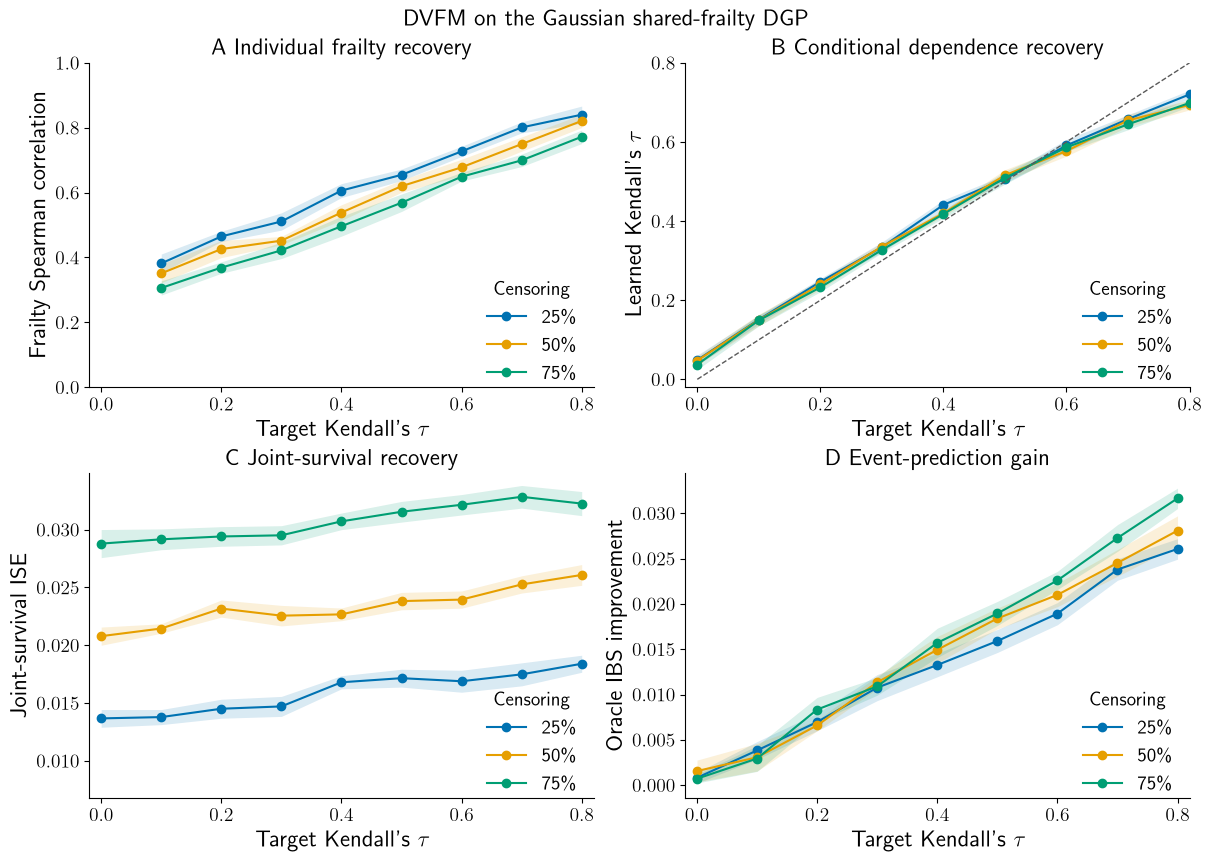

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_main.pdf


In [3]:
def mean_ci(frame, groups, metric):
    out = frame.groupby(groups)[metric].agg(["mean", "std", "count"]).reset_index()
    out["ci95"] = 1.96 * out["std"].fillna(0) / np.sqrt(out["count"].clip(lower=1))
    return out

def draw_matrix(matrix, ax, title, cmap="viridis", center=None, fmt=".3f", vmin=None, vmax=None):
    values = matrix.to_numpy(dtype=float)
    if center is None:
        image = ax.imshow(values, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    else:
        radius = max(float(np.nanmax(np.abs(values - center))), 1e-8)
        image = ax.imshow(values, cmap=cmap, aspect="auto", norm=TwoSlopeNorm(vmin=center-radius, vcenter=center, vmax=center+radius))
    threshold = np.nanmean(values)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            if np.isfinite(values[row, column]):
                ax.text(column, row, format(values[row, column], fmt), ha="center", va="center", color="white" if values[row, column] < threshold else "black", fontsize=11)
    ax.set_xticks(np.arange(matrix.shape[1]), [f"{value:g}" for value in matrix.columns])
    ax.set_yticks(np.arange(matrix.shape[0]), [f"{value:g}" for value in matrix.index])
    ax.set_title(title, loc="left", fontweight="bold")
    return image

def heatmap(frame, value, ax, title, cmap="viridis", center=None, fmt=".3f"):
    matrix = frame.pivot(index="target_censoring_rate", columns="target_kendall_tau", values=value)
    draw_matrix(matrix, ax, title, cmap=cmap, center=center, fmt=fmt)
    ax.set_xlabel(r"Target Kendall's $\tau$")
    ax.set_ylabel("Censoring rate")

z1 = raw[pd.to_numeric(raw["latent_dim"], errors="coerce").eq(1)].copy()
frailty_all = diagnostics[diagnostics["subgroup"].eq("all")].copy()
frailty_summary = mean_ci(frailty_all, ["target_kendall_tau", "target_censoring_rate"], "frailty_spearman")
frailty_summary = frailty_summary[frailty_summary["target_kendall_tau"].gt(0)].copy()
tau_summary = mean_ci(z1, ["target_kendall_tau", "target_censoring_rate"], "learned_conditional_kendall_tau")
joint_summary = mean_ci(z1, ["target_kendall_tau", "target_censoring_rate"], "oracle_joint_survival_ise")

ibs_wide = raw.pivot_table(index=["repeat", "target_kendall_tau", "target_censoring_rate"], columns="latent_dim", values="oracle_ibs").reset_index()
ibs_wide["oracle_ibs_gain"] = ibs_wide[0] - ibs_wide[1]
gain_summary = mean_ci(ibs_wide, ["target_kendall_tau", "target_censoring_rate"], "oracle_ibs_gain")

fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.5), constrained_layout=True)
colors = dict(zip((0.25, 0.50, 0.75), ("#0072B2", "#E69F00", "#009E73")))
for censoring, part in frailty_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
    axes[0, 0].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[0, 0].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[0, 0].set(title="A  Individual frailty recovery", xlabel=r"Target Kendall's $\tau$", ylabel="Frailty Spearman correlation", xlim=(-0.02, 0.82), ylim=(0, 1))
axes[0, 0].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))

for censoring, part in tau_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
    axes[0, 1].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[0, 1].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[0, 1].plot([0, 0.8], [0, 0.8], color="0.35", linestyle="--", linewidth=1)
axes[0, 1].set(title=r"B  Conditional dependence recovery", xlabel=r"Target Kendall's $\tau$", ylabel=r"Learned Kendall's $\tau$", xlim=(-0.02, 0.80), ylim=(-0.02, 0.80))
axes[0, 1].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))

for censoring, part in joint_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
    axes[1, 0].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[1, 0].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[1, 0].set(title="C  Joint-survival recovery", xlabel=r"Target Kendall's $\tau$", ylabel="Joint-survival ISE", xlim=(-0.02, 0.82))
joint_ymin, joint_ymax = axes[1, 0].get_ylim()
axes[1, 0].set_ylim(joint_ymin - 0.22 * (joint_ymax - joint_ymin), joint_ymax)
axes[1, 0].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))

for censoring, part in gain_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
    axes[1, 1].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[1, 1].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[1, 1].set(title="D  Event-prediction gain", xlabel=r"Target Kendall's $\tau$", ylabel="Oracle IBS improvement", xlim=(-0.02, 0.82))
axes[1, 1].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))
fig.suptitle("DVFM on the Gaussian shared-frailty DGP", fontweight="bold")
out = FIGURE_DIR / "synthetic_main.pdf"
fig.savefig(out)
plt.show()
print(f"{DATA_SOURCE} | wrote {out}")

## Appendix diagnostic: recovery by observed subgroup

This separates all test subjects, observed-event subjects, and censored subjects. The primary paper should use the compact all-subject curve above unless subgroup differences are scientifically important.

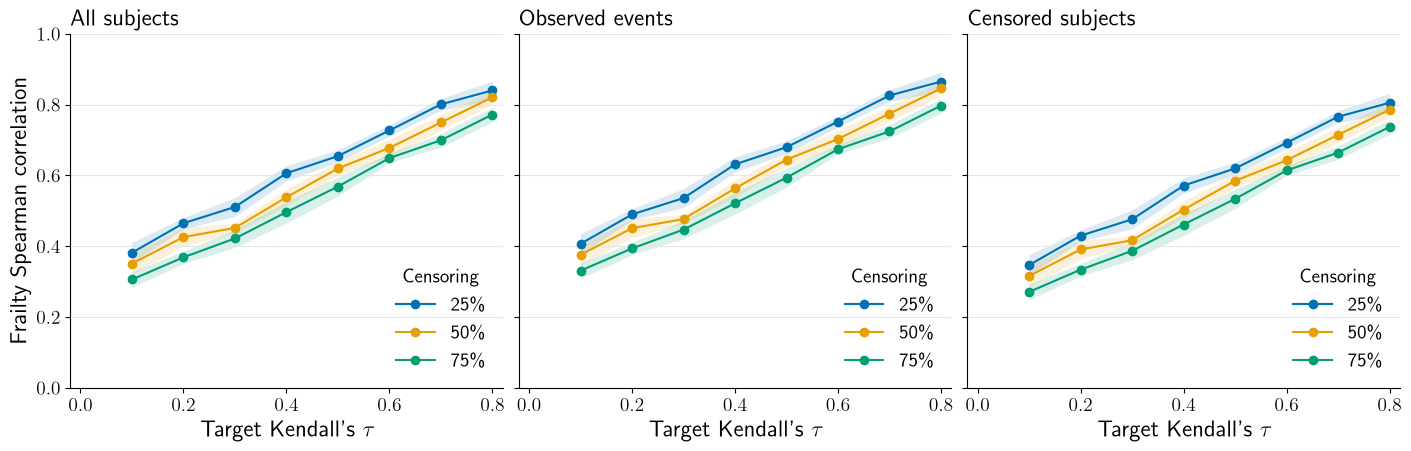

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_frailty_subgroups.pdf


In [4]:
labels = {"all": "All subjects", "event_observed": "Observed events", "censored": "Censored subjects"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True, constrained_layout=True)
for ax, subgroup in zip(axes, labels):
    subgroup_rows = diagnostics[diagnostics["subgroup"].eq(subgroup) & diagnostics["target_kendall_tau"].gt(0)]
    summary = mean_ci(subgroup_rows, ["target_kendall_tau", "target_censoring_rate"], "frailty_spearman")
    for censoring, part in summary.groupby("target_censoring_rate"):
        part = part.sort_values("target_kendall_tau")
        x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
        ax.fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
        ax.plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
    ax.set_title(labels[subgroup], loc="left", fontweight="bold")
    ax.set_xlabel(r"Target Kendall's $\tau$")
    ax.set_xlim(-0.02, 0.82)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.legend(title="Censoring", loc="lower right", frameon=False)
axes[0].set_ylabel("Frailty Spearman correlation")
out = FIGURE_DIR / "synthetic_frailty_subgroups.pdf"
fig.savefig(out)
plt.show()
print(f"{DATA_SOURCE} | wrote {out}")